In [2]:
import os
import numpy as np
import pandas as pd             

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             accuracy_score)
import matplotlib.pyplot as plt
import seaborn as sns

import joblib 
import json


In [3]:
DATA_PATH = "diabetes.csv"

try:
    df = pd.read_csv(DATA_PATH)
    print(f"Data loaded successfully! Shape: {df.shape}")
    display(df.head())
except FileNotFoundError:
    print(f"File {DATA_PATH} not found! Please place the diabetes.csv file in the same directory.")

Data loaded successfully! Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
print("\n=== Data Info ===")
display(df.info())
print("\n=== Statistical Summary ===")
display(df.describe().T)


=== Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


None


=== Statistical Summary ===


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


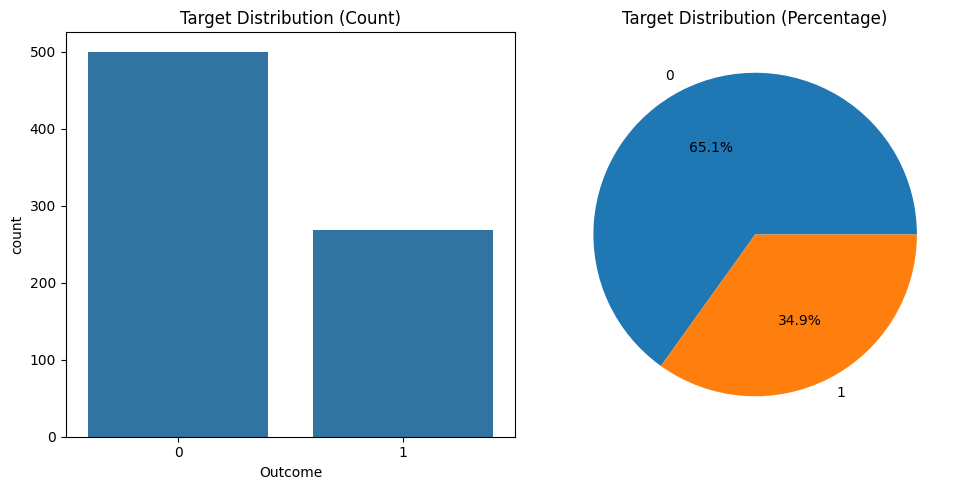

Target Distribution:
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


In [5]:
target_col = "Outcome"

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.countplot(x=target_col, data=df)
plt.title("Target Distribution (Count)")

plt.subplot(1, 2, 2)
df[target_col].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Target Distribution (Percentage)")
plt.ylabel('')

plt.tight_layout()
plt.show()

print("Target Distribution:")
print(df[target_col].value_counts(normalize=True))

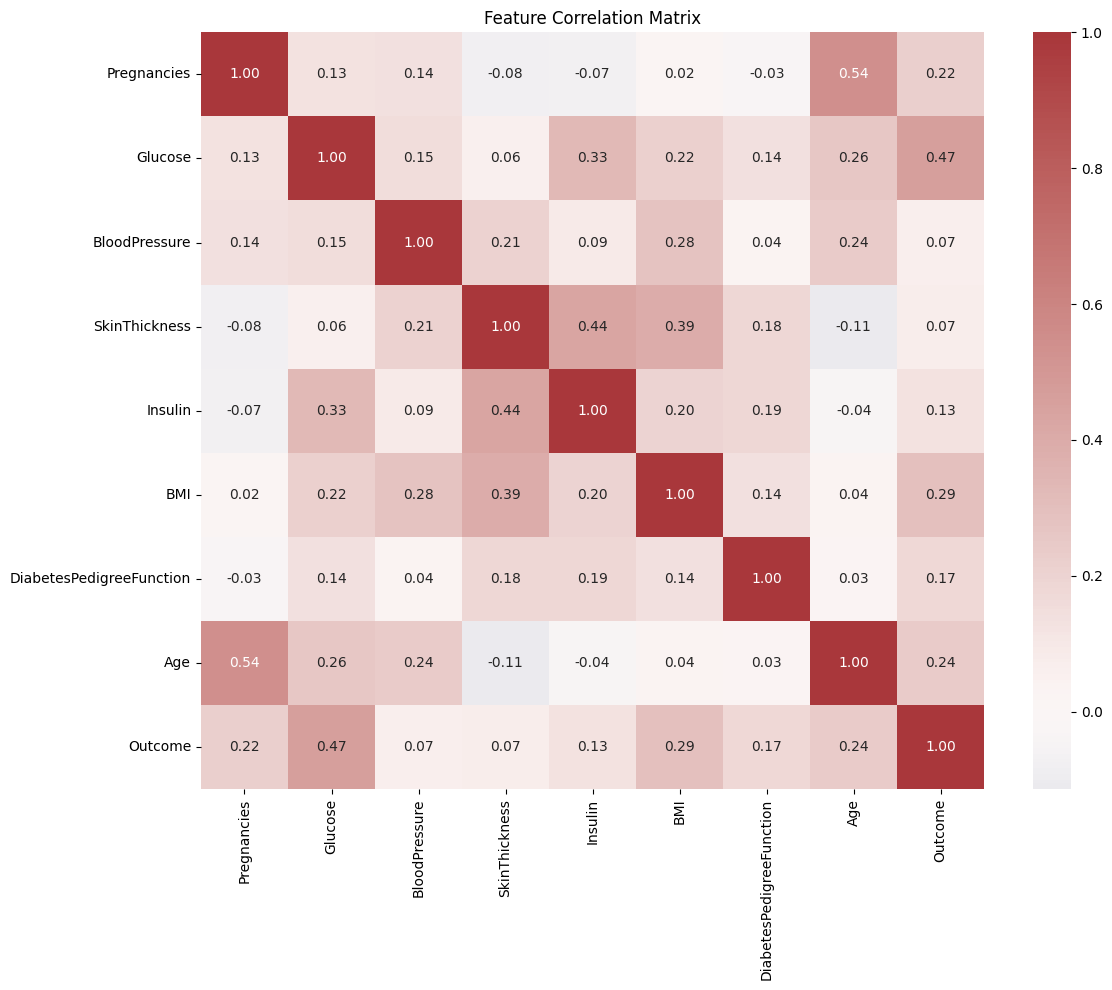

In [41]:
# Correlation Analysis
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [7]:
# Data Cleaning and Preprocessing

invalid_zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

print("Before cleaning:")
for col in invalid_zero_cols:
    zero_count = (df[col] == 0).sum()
    print(f"{col}: {zero_count} zeros ({zero_count/len(df)*100:.1f}%)")

for col in invalid_zero_cols:
    df[col] = df[col].replace(0, np.nan)

print("\nMissing values after marking zeros as NaN:")
display(df.isna().sum())

for col in invalid_zero_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"{col}: filled with median = {median_val:.2f}")

print("\nMissing values after imputation:")
display(df.isna().sum())


Before cleaning:
Glucose: 5 zeros (0.7%)
BloodPressure: 35 zeros (4.6%)
SkinThickness: 227 zeros (29.6%)
Insulin: 374 zeros (48.7%)
BMI: 11 zeros (1.4%)

Missing values after marking zeros as NaN:


Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Glucose: filled with median = 117.00
BloodPressure: filled with median = 72.00
SkinThickness: filled with median = 29.00
Insulin: filled with median = 125.00
BMI: filled with median = 32.30

Missing values after imputation:


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
print("=== Feature Engineering ===")

# Create a copy for feature engineering
df_processed = df.copy()

# Age 
if "Age" in df_processed.columns:
    df_processed["Age_group"] = pd.cut(df_processed["Age"], 
                                     bins=[0, 30, 45, 60, 100], 
                                     labels=["Young", "Middle", "Senior", "Elder"])
    print("Age groups created")

# BMI 
if "BMI" in df_processed.columns:
    def categorize_bmi(bmi):
        if bmi < 18.5:
            return "Underweight"
        elif bmi < 25:
            return "Normal"
        elif bmi < 30:
            return "Overweight"
        else:
            return "Obese"
    
    df_processed["BMI_category"] = df_processed["BMI"].apply(categorize_bmi)
    print("BMI categories created")

# Interaction 
if {"BMI", "Age"}.issubset(df_processed.columns):
    df_processed["BMI_Age_interaction"] = df_processed["BMI"] * df_processed["Age"]
    print("BMI-Age interaction feature created")

# Glucose 
if "Glucose" in df_processed.columns:
    df_processed["Glucose_category"] = pd.cut(df_processed["Glucose"],
                                            bins=[0, 100, 125, 200],
                                            labels=["Normal", "Prediabetic", "Diabetic"])
    print("Glucose categories created")


categorical_cols = df_processed.select_dtypes(include=['category', 'object']).columns
if len(categorical_cols) > 0:
    df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)
    print(f"One-hot encoded columns: {list(categorical_cols)}")

print(f"Final dataset shape: {df_processed.shape}")
display(df_processed.head())

=== Feature Engineering ===
Age groups created
BMI categories created
BMI-Age interaction feature created
Glucose categories created
One-hot encoded columns: ['Age_group', 'BMI_category', 'Glucose_category']
Final dataset shape: (768, 18)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Age_interaction,Age_group_Middle,Age_group_Senior,Age_group_Elder,BMI_category_Obese,BMI_category_Overweight,BMI_category_Underweight,Glucose_category_Prediabetic,Glucose_category_Diabetic
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,1680.0,False,True,False,True,False,False,False,True
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,824.6,True,False,False,False,True,False,False,False
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,745.6,True,False,False,False,False,False,False,True
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,590.1,False,False,False,False,True,False,False,False
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,1422.3,True,False,False,True,False,False,False,True


In [9]:
# Data Splitting and Scaling
TARGET = target_col
X = df_processed.drop(columns=[TARGET])
y = df_processed[TARGET]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Split data: 70% train, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")

# Scale 
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical columns to scale: {len(numerical_cols)}")

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_val_scaled[numerical_cols] = scaler.transform(X_val[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])


joblib.dump(scaler, "models/scaler.joblib")
joblib.dump(numerical_cols, "models/numerical_cols.joblib")
joblib.dump(X.columns.tolist(), "models/feature_columns.joblib")

print("Scaler and feature info saved!")


Features shape: (768, 17)
Target shape: (768,)
Train shape: (537, 17)
Validation shape: (115, 17)
Test shape: (116, 17)
Numerical columns to scale: 9
Scaler and feature info saved!


In [10]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression

print("=== Baseline Model: Logistic Regression ===")


lr_pipeline = make_pipeline(
    SimpleImputer(strategy='mean'),
    LogisticRegression(max_iter=1000, random_state=42)
)


lr_pipeline.fit(X_train, y_train)


y_pred_lr = lr_pipeline.predict(X_test)
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

# Evaluate
print("Logistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_proba_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

=== Baseline Model: Logistic Regression ===
Logistic Regression Results:
Accuracy: 0.7500
ROC AUC: 0.8670

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.89      0.82        75
           1       0.71      0.49      0.58        41

    accuracy                           0.75       116
   macro avg       0.74      0.69      0.70       116
weighted avg       0.74      0.75      0.74       116



D:\python_programmes\diabates_ML\env\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [11]:
print("=== Neural Network Model ===")

def create_model(input_shape, dropout_rate=0.3):
    """
    Create a neural network model for binary classification
    """
    model = keras.Sequential([
        layers.Input(shape=(input_shape,)),
        layers.Dense(128, activation="relu", name="hidden_1"),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),
        
        layers.Dense(64, activation="relu", name="hidden_2"),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),
        
        layers.Dense(32, activation="relu", name="hidden_3"),
        layers.Dropout(dropout_rate/2),
        
        layers.Dense(1, activation="sigmoid", name="output")
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["AUC", "accuracy", "precision", "recall"]
    )
    
    return model

# Create model
input_shape = X_train_scaled.shape[1]
model = create_model(input_shape)
model.summary()


=== Neural Network Model ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                     │ (None, 128)                 │           2,304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hidden_2 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hidden_3 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,441 (52.50 KB)

 Trainable params: 13,057 (51.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [12]:

print("=== Training Neural Network ===")


callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=10,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        "models/best_model.keras",
        save_best_only=True,
        monitor="val_auc",
        mode="max",
        verbose=1
    )
]


history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print("Training completed!")

=== Training Neural Network ===
Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - AUC: 0.6146 - accuracy: 0.6257 - loss: 0.7347 - precision: 0.4611 - recall: 0.4439 - val_AUC: 0.7820 - val_accuracy: 0.6957 - val_loss: 0.6101 - val_precision: 0.6000 - val_recall: 0.3750 - learning_rate: 0.0010
Epoch 2/100


D:\python_programmes\diabates_ML\env\Lib\site-packages\keras\src\callbacks\model_checkpoint.py:276: UserWarning: Can save best model only with val_auc available.
  if self._should_save_model(epoch, batch, logs, filepath):


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - AUC: 0.7902 - accuracy: 0.7467 - loss: 0.5577 - precision: 0.6321 - recall: 0.6524 - val_AUC: 0.7987 - val_accuracy: 0.7304 - val_loss: 0.5762 - val_precision: 0.6452 - val_recall: 0.5000 - learning_rate: 0.0010
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - AUC: 0.7797 - accuracy: 0.7263 - loss: 0.5728 - precision: 0.6149 - recall: 0.5722 - val_AUC: 0.7938 - val_accuracy: 0.7217 - val_loss: 0.5689 - val_precision: 0.6250 - val_recall: 0.5000 - learning_rate: 0.0010
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - AUC: 0.8100 - accuracy: 0.7542 - loss: 0.5237 - precision: 0.6627 - recall: 0.5989 - val_AUC: 0.8015 - val_accuracy: 0.7304 - val_loss: 0.5567 - val_precision: 0.6552 - val_recall: 0.4750 - learning_rate: 0.0010
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - AUC: 0.8136 - accuracy: 0.7691 - loss: 0.5015 - precision: 0.6909 - recall: 0.6096 - val_AUC: 0.8078 - val_accuracy: 0.7304 - val_loss: 0.5409 - val_precision: 0.6

=== Training History ===
Available metrics: dict_keys(['AUC', 'accuracy', 'loss', 'precision', 'recall', 'val_AUC', 'val_accuracy', 'val_loss', 'val_precision', 'val_recall', 'learning_rate'])
AUC not available in the training history.


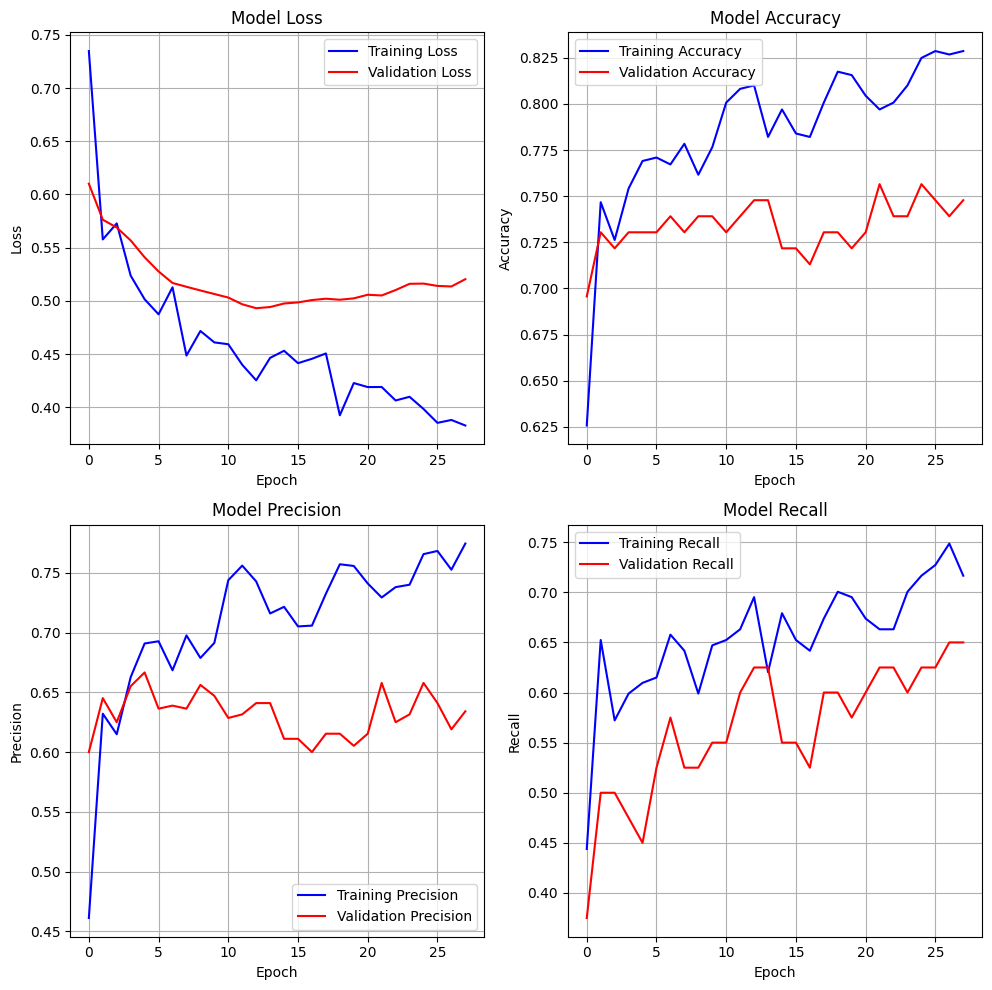

In [15]:

print("=== Training History ===")


print("Available metrics:", history.history.keys())


hist_df = pd.DataFrame(history.history)


plt.figure(figsize=(15, 10))


plt.subplot(2, 3, 1)
plt.plot(hist_df["loss"], label="Training Loss", color='blue')
plt.plot(hist_df["val_loss"], label="Validation Loss", color='red')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)


plt.subplot(2, 3, 2)
plt.plot(hist_df["accuracy"], label="Training Accuracy", color='blue')
plt.plot(hist_df["val_accuracy"], label="Validation Accuracy", color='red')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)


if 'auc' in hist_df.columns and 'val_auc' in hist_df.columns:
    plt.subplot(2, 3, 3)
    plt.plot(hist_df["auc"], label="Training AUC", color='blue')
    plt.plot(hist_df["val_auc"], label="Validation AUC", color='red')
    plt.title("Model AUC")
    plt.xlabel("Epoch")
    plt.ylabel("AUC")
    plt.legend()
    plt.grid(True)
else:
    print("AUC not available in the training history.")


if 'precision' in hist_df.columns and 'val_precision' in hist_df.columns:
    plt.subplot(2, 3, 4)
    plt.plot(hist_df["precision"], label="Training Precision", color='blue')
    plt.plot(hist_df["val_precision"], label="Validation Precision", color='red')
    plt.title("Model Precision")
    plt.xlabel("Epoch")
    plt.ylabel("Precision")
    plt.legend()
    plt.grid(True)
else:
    print("Precision not available in the training history.")


if 'recall' in hist_df.columns and 'val_recall' in hist_df.columns:
    plt.subplot(2, 3, 5)
    plt.plot(hist_df["recall"], label="Training Recall", color='blue')
    plt.plot(hist_df["val_recall"], label="Validation Recall", color='red')
    plt.title("Model Recall")
    plt.xlabel("Epoch")
    plt.ylabel("Recall")
    plt.legend()
    plt.grid(True)
else:
    print("Recall not available in the training history.")

plt.tight_layout()
plt.show()


=== Model Evaluation ===
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Neural Network Results:
Accuracy: 0.7759
ROC AUC: 0.8611

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.85      0.83        75
           1       0.70      0.63      0.67        41

    accuracy                           0.78       116
   macro avg       0.76      0.74      0.75       116
weighted avg       0.77      0.78      0.77       116



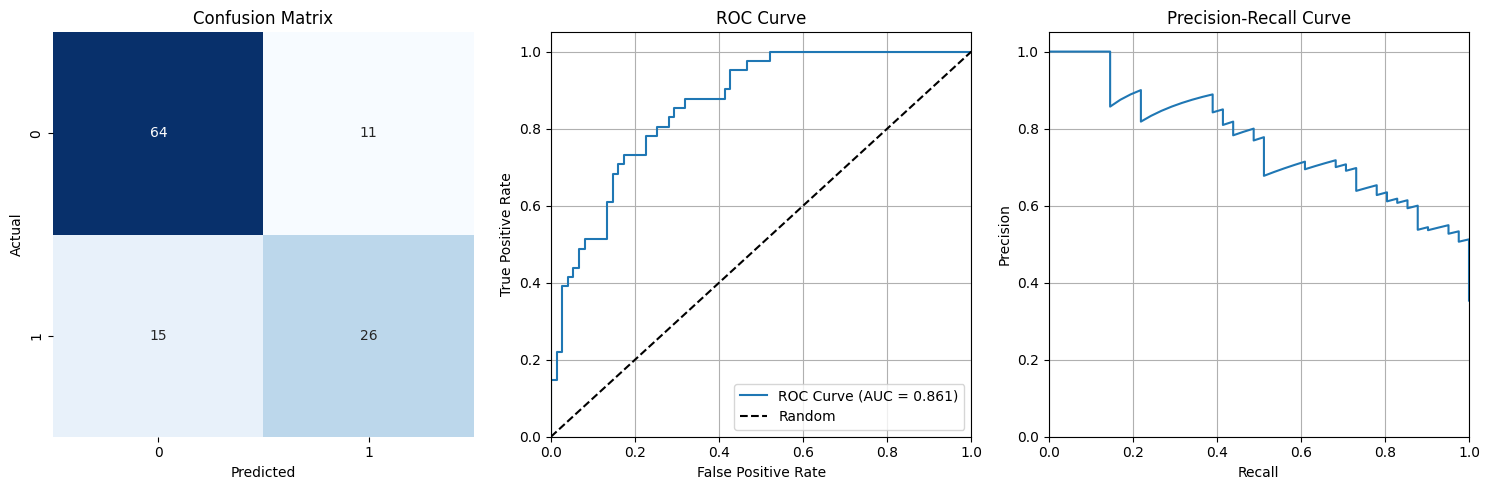

In [16]:

print("=== Model Evaluation ===")

# Load model
model = keras.models.load_model("models/best_model.keras")

# Make predictions
y_proba = model.predict(X_test_scaled).ravel()
y_pred = (y_proba >= 0.5).astype(int)


accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("Neural Network Results:")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# ROC Curve
plt.subplot(1, 3, 2)
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)

# Precision-Recall Curve
plt.subplot(1, 3, 3)
precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.plot(recall, precision)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)

plt.tight_layout()
plt.show()


In [17]:
X_train.dtypes

Pregnancies                       int64
Glucose                         float64
BloodPressure                   float64
SkinThickness                   float64
Insulin                         float64
BMI                             float64
DiabetesPedigreeFunction        float64
Age                               int64
BMI_Age_interaction             float64
Age_group_Middle                   bool
Age_group_Senior                   bool
Age_group_Elder                    bool
BMI_category_Obese                 bool
BMI_category_Overweight            bool
BMI_category_Underweight           bool
Glucose_category_Prediabetic       bool
Glucose_category_Diabetic          bool
dtype: object

In [18]:
print("=== Saving Model and Metadata ===")

# Save trained model
model.save("models/diabetes_model.keras")


metadata = {
    "model_type": "neural_network",
    "target_column": TARGET,
    "feature_columns": X.columns.tolist(),
    "numerical_columns": numerical_cols,
    "model_metrics": {
        "accuracy": float(accuracy),
        "roc_auc": float(roc_auc)
    },
    "feature_engineering": {
        "invalid_zero_cols": invalid_zero_cols,
        "scaling": "StandardScaler"
    }
}

with open("models/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Model and metadata saved successfully!")
print("Files saved:")
print("- models/diabetes_model.keras")
print("- models/scaler.joblib")
print("- models/numerical_cols.joblib")
print("- models/feature_columns.joblib")
print("- models/metadata.json")

=== Saving Model and Metadata ===
Model and metadata saved successfully!
Files saved:
- models/diabetes_model.keras
- models/scaler.joblib
- models/numerical_cols.joblib
- models/feature_columns.joblib
- models/metadata.json


In [19]:
def predict_diabetes(patient_data):
    """
    Predict diabetes for a single patient
    
    Args:
        patient_data (dict): Dictionary containing patient features
        
    Returns:
        dict: Prediction results with probability and label
    """
    try:
        
        model = keras.models.load_model("models/diabetes_model.keras")
        scaler = joblib.load("models/scaler.joblib")
        numerical_cols = joblib.load("models/numerical_cols.joblib")
        feature_columns = joblib.load("models/feature_columns.joblib")
        
        
        df_sample = pd.DataFrame([patient_data])
        
        for col in feature_columns:
            if col not in df_sample.columns:
                df_sample[col] = 0
        
        
        df_sample = df_sample[feature_columns]
        
        
        df_sample[numerical_cols] = scaler.transform(df_sample[numerical_cols])
        
        
        probability = model.predict(df_sample).ravel()[0]
        label = int(probability >= 0.5)
        
        return {
            "probability": float(probability),
            "risk_level": "High Risk" if label == 1 else "Low Risk",
            "confidence": float(max(probability, 1-probability)),
            "label": label
        }
        
    except Exception as e:
        return {"error": str(e)}


test_patient = {
    "Pregnancies": 2,
    "Glucose": 120,
    "BloodPressure": 80,
    "SkinThickness": 20,
    "Insulin": 100,
    "BMI": 25.0,
    "DiabetesPedigreeFunction": 0.5,
    "Age": 45
}

result = predict_diabetes(test_patient)
print("Test Prediction:")
print(f"Patient: {test_patient}")
print(f"Result: {result}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Test Prediction:
Patient: {'Pregnancies': 2, 'Glucose': 120, 'BloodPressure': 80, 'SkinThickness': 20, 'Insulin': 100, 'BMI': 25.0, 'DiabetesPedigreeFunction': 0.5, 'Age': 45}
Result: {'probability': 0.02353314310312271, 'risk_level': 'Low Risk', 'confidence': 0.9764668345451355, 'label': 0}
